In [14]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.io
from scipy.stats import spearmanr, pearsonr

#=================================================================================================#

from utils import interventional as IC
from utils import load_data as ld
from utils import load_EC as lec
from utils import colormaps as maps
from utils import plot as pl
from utils import correlations as cc
from utils import distance as di

#=================================================================================================#

In [15]:
#=================================================================================================#
# For Avenir font. To use it, you have to download the font-style files below.
# Comment the lines referred to fontManager if you don't need to set the font.
from matplotlib import font_manager, rcParams
font_file   = "/home/tentori/.local/avenir_ff/AvenirLTStd-Roman.otf"
font_file_b = "/home/tentori/.local/avenir_ff/AvenirLTStd-Black.otf"
font_file_c = "/home/tentori/.local/avenir_ff/AvenirLTStd-Book.otf"
font_manager.fontManager.addfont(font_file)
font_manager.fontManager.addfont(font_file_b)
font_manager.fontManager.addfont(font_file_c)
#------------------------------------------------------------#
rcParams['font.family']  = "Avenir LT Std"
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype']  = 42
#------------------------------------------------------------#
DIM = 25
plt.rcParams.update({'font.size': DIM,'axes.labelsize': DIM,'axes.titlesize': DIM,'xtick.labelsize': DIM,'ytick.labelsize': DIM})
#=================================================================================================#
# Colors
colorz    = ['#255D93','#5FA6D6','#B02106','#F24D33','#2C2C2C','#787878']
coldhot_cmap   = maps.create_cmaphot()
coldhot_cmap_r = maps.create_cmaphot_r()
#------------------------------------------------------------#
show_plot   = True
#------------------------------------------------------------#
from cmap import Colormap
def Cmap(cmap):
    return Colormap(cmap).to_mpl()
#------------------------------------------------------------#
def truncate_cmap(cmap, minval=0.0, maxval=0.8, n=256):
    from matplotlib.colors import Normalize, LinearSegmentedColormap
    return LinearSegmentedColormap.from_list( f'{cmap.name}_trunc', cmap(np.linspace(minval, maxval, n)) )
#------------------------------------------------------------#
def discrete_cmap(cmap_name='turbo', num_colors=25, minval=0., maxval=1):
    from matplotlib.colors import ListedColormap
    base = truncate_cmap(plt.get_cmap(cmap_name), minval=minval, maxval=maxval)
    return ListedColormap(base(np.linspace(0, 1, num_colors)))
cmap=truncate_cmap(plt.get_cmap('Blues'), minval=0.1, maxval=1)
#=================================================================================================#
# to create folder
def Set_Dir_Plots(path):
    import os
    if not os.path.exists(path):
        os.mkdir(path)
#=================================================================================================#


## Functions

In [16]:
def ic_save(_path_,ic,ic_pval,ic_pval_FDR,suffix=''):
    
    import pickle
    with open(_path_+'ks'+suffix+'.pkl', 'wb') as f:
        pickle.dump(ic, f)

    with open(_path_+'ks_pval'+suffix+'.pkl', 'wb') as f:
        pickle.dump(ic_pval, f)

    with open(_path_+'ks_pval_FDR'+suffix+'.pkl', 'wb') as f:
        pickle.dump(ic_pval_FDR, f)
        
def ic_load(_path_,suffix=''):
    
    with open(_path_+'ks'+suffix+'.pkl', 'rb') as f:
        ic = pickle.load(f)

    with open(_path_+'ks_pval'+suffix+'.pkl', 'rb') as f:
        ic_pval = pickle.load(f)
        
    with open(_path_+'ks_pval_FDR'+suffix+'.pkl', 'rb') as f:
        ic_pval_FDR = pickle.load(f)
        
    return ic, ic_pval, ic_pval_FDR

In [17]:
def erase_artifacts(channel, def_units, def_spikes, Tstim_start_s=1, Tstim_duration_s=0.12, Tonset_duration=0.12,
                     erase_min=1.00-0.001, erase_max=1.12, erase_first=0.0, ipi_sec=0.001, Ntrials=200, fs=20000):

    erase_min_samp   = int(round(erase_min   * fs))
    erase_max_samp   = int(round(erase_max   * fs))
    erase_first_samp = int(round(erase_first * fs))
    
    Tstim_start_s_samp    = int(round(Tstim_start_s    * fs))
    Tstim_duration_s_samp = int(round(Tstim_duration_s * fs))
    Tonset_duration_samp  = int(round(Tonset_duration  * fs))
    ipi_samp              = int(round(ipi_sec          * fs))
    
    # ---- erase spikes during stimulation and the trial onset ----
    modified_spikes = {}
    for n_stim in def_units:
        modified_spikes[n_stim] = {}
        for n_trial in range(Ntrials):
            modified_spikes[n_stim][n_trial] = {}
            for n_channel in range(1024):
                s                 = def_spikes[n_stim][n_trial][n_channel]
                cond_outside_stim = (s < erase_min_samp) | (s >= erase_max_samp)
                cond_after_first  = s > erase_first_samp
                modified_spikes[n_stim][n_trial][n_channel] = s[cond_outside_stim & cond_after_first]
                
    return modified_spikes

In [18]:
def stack_trials(channel, def_units, spikes, T_spont=1800., DeltaT_sec=3., Ntrials=200, fs=20000, path_out=None, one=False):

    DeltaT  = int(DeltaT_sec * fs)
    n_units = len(def_units)  # n. stimulation channels
    
    # Global start times
    total_blocks = n_units * Ntrials
    T_starts     = int(T_spont * fs) + np.arange(total_blocks) * DeltaT
    
    spikeTimes_list = []
    spikeChannels_list = []

    block_idx = 0
    for trial in range(Ntrials):
        for unitID in def_units:
            block_spike_times = []
            block_spike_chans = []
            
            for ch in channel:
                t_ = spikes[unitID][trial][ch]
                t_ = t_[t_ < DeltaT]
                if t_.size == 0:
                    continue
                block_spike_times.append(t_)
                block_spike_chans.append(np.repeat(ch, t_.size))
    
            if block_spike_times:
                block_spike_times = np.concatenate(block_spike_times) + T_starts[block_idx]
                block_spike_chans = np.concatenate(block_spike_chans)
    
                spikeTimes_list.append(block_spike_times)
                spikeChannels_list.append(block_spike_chans)
    
            block_idx += 1
            
    # Concatenate all spike data
    if spikeTimes_list:
        spikeTimes    = np.concatenate(spikeTimes_list)
        spikeChannels = np.concatenate(spikeChannels_list)
    else:
        spikeTimes    = np.array([])
        spikeChannels = np.array([])
    
    # Final sort
    sort_idx      = np.argsort(spikeTimes)
    spikeTimes    = spikeTimes[sort_idx]
    spikeChannels = spikeChannels[sort_idx]
    
    if path_out is not None:
        data = np.column_stack((spikeChannels, spikeTimes.astype(int)))
        np.save(path_out + "spikeTimes_stimulation.npy", data)
    
    return spikeTimes, spikeChannels
#----------------------------------------------------------------------------------------------------------------------------#


In [19]:
def compute_spike_counts(spikes, binsize=0.02):
    """
    Estimate spike counts in bins of given size and return a T x N array.
    
    Parameters:
    spikes (numpy array): 2D array with first row as spike times in seconds and second row as neuron IDs.
    binsize (float):      Size of the bins in seconds. Default is 20ms.
    
    Returns:
    numpy array:          T x N array with spike counts, where T is the number of bins and N is the number of neurons.
    """
    # Extract spike times and neuron IDs
    spike_times = spikes[0]
    neuron_ids  = spikes[1].astype(int)
    
    # Determine the number of unique neurons
    unique_neurons = np.unique(neuron_ids)
    num_neurons    = len(unique_neurons)
    
    # Map neuron IDs to a continuous range starting from 0
    neuron_id_map     = {neuron_id: i for i, neuron_id in enumerate(unique_neurons)}
    mapped_neuron_ids = np.array([neuron_id_map[neuron_id] for neuron_id in neuron_ids])
    
    # Convert spike times to bin indices
    spike_bins   = (spike_times / binsize).astype(int)
    
    # Determine the number of bins
    num_bins     = spike_bins.max() + 1
    
    # Initialize the T x N array with zeros
    spike_counts = np.zeros((num_bins, num_neurons), dtype=int)
    
    # Use np.add.at to accumulate spike counts
    np.add.at(spike_counts, (spike_bins, mapped_neuron_ids), 1)
    
    return spike_counts

In [41]:
def sort_units_with_distance(i, channel, pos, def_units, def_chans):
    
    def eucl_dist(a1, a2):
        return np.sqrt( (a1[0]-a2[0])*(a1[0]-a2[0]) + (a1[1]-a2[1])*(a1[1]-a2[1]) )
    
    ch = channel[i]

    # dist between ch and stim. chans.
    distances = np.zeros(len(def_units))
    for idx in range(len(def_units)):
        id1 = np.where(channel==def_chans[idx])[0][0]
        id2 = np.where(channel==ch)[0][0]
        distances[idx] = eucl_dist(pos[id1,:],pos[id2,:])
    
    # stim. channels ordered in increasing distance
    L = np.argsort(distances)
    return L[::-1], distances[L[::-1]]

def despine_all(fig):
    for ax in fig.axes:
        for side in ("left", "right", "top", "bottom"):
            ax.spines[side].set_visible(False)
        ax.tick_params(left=False, right=False, top=False, bottom=False)

### Plots

In [20]:
def plot_mat_aspect(mat, cmap='viridis', title=None, xlabel='time (s)', ylabel='channel ID', cbarlabel='spike count', vmin=None, vmax=None,
                    inevert_y : bool = True, figsize=(15,5), outf : str = None, show_plot = True):
    mat_max = np.max(mat.flatten())
    #vmin=0.6; vmax=0.1
    if vmin==None or vmax==None:
        vmin,vmax = np.percentile(mat.flatten()/mat_max,[2.5,97.5])
    else:
        pass
    fig,ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat/mat_max, aspect='auto', vmin=vmin,vmax=vmax, cmap=cmap)
    print(vmin,vmax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        plt.title(title)
    cbar = fig.colorbar(im, ax=ax, label=cbarlabel)
    if inevert_y:
        ax.invert_yaxis()
    
    if outf:
        plt.savefig(outf, bbox_inches='tight')
    
    if show_plot == False:
        plt.close()
    else:
        plt.show()

In [21]:
def plot_scatter(ic_mat, ec_mat, zeroExp=-11, log=False, xlabel='IC', ylabel='EC', title=None, dotsize=0.1, 
                 cmap=None, edgecolor=None, linewidths=0.2, regcolor='tab:red', dotcolor='tab:blue', reg_line=False, show_corr=True,
                 xmin=None, xmax=None, ymin=None, ymax=None, ax=None, alpha=1, figsize=(3.5,3), outf=None, show_plot=False):
    import seaborn as sns
    from scipy.stats import pearsonr, spearmanr, gaussian_kde
    ic_vec = ic_mat.flatten()
    if log:
        ec_vec = np.log10(ec_mat.flatten()+10**zeroExp)
        x=ic_vec[ec_mat.flatten()!=0]
        y=ec_vec[ec_mat.flatten()!=0]
    else:
        ec_vec = ec_mat.flatten()
        x=ic_vec
        y=ec_vec

    if ymin is not None and ymax is not None:
        y_ = np.copy(y)        
        x = x[(y_>=ymin) & (y_<ymax)]
        y = y_[(y_>=ymin) & (y_<ymax)]
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
        
    if cmap:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        vmax = np.max(z); vmin = vmax; 
        # Plot with density-based color
        scatter = ax.scatter(x, y, c=z, s=dotsize, edgecolor=edgecolor, linewidths=linewidths, cmap=cmap, alpha=alpha)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
        cbar.set_label(r'density', fontsize=DIM)
        cbar.ax.tick_params(labelsize=DIM)
    else:
        ax.scatter(x, y, s=dotsize, c=dotcolor, edgecolor=edgecolor, linewidths=linewidths, alpha=alpha)

    if reg_line:
        sns.regplot(x=x, y=y, ax=ax, scatter=False, color=regcolor, line_kws={'linewidth': 1})
    
    if show_corr:
        cp = np.round(pearsonr(ic_vec,ec_vec)[0],2)
        cs = np.round(spearmanr(ic_vec,ec_vec)[0],2)
        pval_p = pearsonr(ic_vec,ec_vec)[1]
        pval_s = spearmanr(ic_vec,ec_vec)[1]
        if title:
            ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
    else:
        if title:
            ax.set_title(title)
        
    if ymin is not None and ymax is not None:
        ax.set_ylim(ymin,ymax)
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin,xmax)
        
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel);

    if cmap:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = cbar, pwr_cbar_min=-2, pwr_cbar_max=2,  DIM = DIM)
    else:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = None, DIM = DIM)

    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [22]:
def plot_scatterColor(x_mat, y_mat, color_vec=None, xlabel='IC', ylabel='EC', title=None, dotsize=0.1, cbar_label='',
                      cmap=None, edgecolor=None, linewidths=0.2, show_corr=True, alpha=0.7, figsize=(3.5,3),
                      vmin_color=None, vmax_color=None, xmin=None, xmax=None, ymin=None, ymax=None, ax=None, outf=None, show_plot=False):
    import seaborn as sns
    from scipy.stats import pearsonr, spearmanr, gaussian_kde

    if color_vec is not None:
        c_vec=color_vec.flatten()
    x = x_mat.flatten()
    y = y_mat.flatten()

    if ymin is not None and ymax is not None:
        y_ = np.copy(y)        
        x = x[(y_>=ymin) & (y_<ymax)]
        y = y_[(y_>=ymin) & (y_<ymax)]
        c_vec = c_vec[(y_>=ymin) & (y_<ymax)]
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
        
    if color_vec is None:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        vmax = np.max(z); vmin = vmax; 
        # Plot with density-based color
        scatter = ax.scatter(x, y, c=z, s=dotsize, edgecolor=edgecolor, linewidths=linewidths, cmap=cmap, alpha=alpha)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
        cbar.set_label('density', fontsize=DIM)
        cbar.ax.tick_params(labelsize=DIM)
    else:
        scatter = ax.scatter(x, y, s=dotsize, c=c_vec, vmin=vmin_color, vmax=vmax_color, edgecolor=edgecolor, linewidths=0.01, cmap=cmap, alpha=alpha)
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
        cbar.set_label(cbar_label, fontsize=DIM)
        cbar.ax.tick_params(labelsize=DIM)

    if show_corr:
        cp = np.round(pearsonr(x,y)[0],2)
        cs = np.round(spearmanr(x,y)[0],2)
        pval_p = pearsonr(x,y)[1]
        pval_s = spearmanr(x,y)[1]
        if title:
            ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$'+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
    else:
        if title:
            ax.set_title(title)
    
    if ymin is not None and ymax is not None:
        ax.set_ylim(ymin,ymax)
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin,xmax)
        
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel);

    if cmap:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = cbar, pwr_cbar_min=-2, pwr_cbar_max=2,  DIM = DIM)
    else:
        pl.set_format(ax, pwr_x_min=-3, pwr_x_max=3, pwr_y_min=-2, pwr_y_max=2, axis_ticks = 'both', cbar = None, DIM = DIM)

    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [45]:
def plot_map_rec(pos_, col_list, channel, def_chans, indices, array_col, cmap=None, cbar_label='', title=None, dotcolor='lightgrey',
                 dotsize=4.5, starsize = 1350, text_dim = 18, dim = 60, font_DIM=30, ncol_leg=2, y_leg=1.2, 
                 figsize=(23, 11), ax=None, outf : str = None, show_plot = True):
    
    pos = pos_[:,:]/1000
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
    
    # Full map of recording channels 
    scatter_rec = ax.scatter(pos[:, 0], pos[:, 1], s=dotsize/2, lw=0.4, marker='s', c=col_list, edgecolor='white',
                             label='rec.', cmap=cmap, zorder=0)
    if cmap is not None:
        cbar        = fig.colorbar(scatter_rec, ax=ax, label=cbar_label)
    
    # stimulation channels
    scatter = ax.scatter(pos[indices, 0], pos[indices, 1], c=array_col, edgecolor='white', s=starsize, marker='*', alpha=1, zorder=1,
                         label='stim.')
    
    plt.xlabel('x (mm)', fontsize=font_DIM);    plt.ylabel('y (mm)', fontsize=font_DIM)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=font_DIM)

    ax.legend(fontsize=font_DIM-5, ncol=ncol_leg, loc='upper center', bbox_to_anchor=(0.5, y_leg),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    
    if title:
        ax.set_title(title)

    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


In [38]:
def plot_channel_map_3(pos_, rec_list, col_list, channel, def_chans, indices, array_col, rec_color='tab:blue', cmap=None, cbar_label='', title=None, dotcolor='lightgrey',
                       dotsize=4.5, starsize = 1350, starsize_center = 50, text_dim = 18, dim = 60, font_DIM=30, ncol_leg=2, y_leg=1.2,
                       rec_text=True, figsize=(23, 11), ax=None, outf : str = None, show_plot = True):
    # optimized for small size plots also
    pos = pos_[:,:]/1000
    
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure() 
        outf=None
    
    # Full map of recording channels 
    ax.scatter(pos[:, 0], pos[:, 1], s=dotsize/2, lw=0.4, marker='s', color=dotcolor, edgecolor='white', zorder=0) #, label='rec. channels')

    # Highlight specific recording channels
    ax.scatter(pos[rec_list, 0], pos[rec_list, 1], s=starsize, c=rec_color, lw=0.4, marker='o',  edgecolor='black', label=f'rec. channels', zorder=0)

    # stimulation channels
    if cmap is not None:
        vmin, vmax = np.percentile(array_col, [2.5, 97.5])
    else:
        vmin, vmax = (None, None)
    scatter = ax.scatter(pos[indices, 0], pos[indices, 1], cmap=cmap, vmin=vmin, vmax=vmax, c=array_col, 
                         edgecolor='white', s=starsize, marker='*', alpha=1, zorder=1, label='stim. channels')
    if starsize_center is not None:
        ax.scatter(pos[indices, 0], pos[indices, 1], color='white', edgecolor='white', linewidths=0.1, 
                   s=starsize_center, marker='*', alpha=1, zorder=3)
    # cmap
    if cmap is not None:
        cbar = fig.colorbar(scatter, ax=ax, label=cbar_label)
    else:
        pass
            
    # labels for rec channels 
    if rec_text is True:
        a = 0
        for i_rec, i_col in zip(rec_list, col_list):
            x = pos[channel == channel[i_rec], 0][0];    y = pos[channel == channel[i_rec], 1][0]
    
            dx, dy = -420, 180
                
            ax.text(x + dx/1000, y + dy/1000, str(i_rec),fontdict=dict(color='k', alpha=1, size=text_dim))
            a += 1
    
    plt.xlabel('x (mm)', fontsize=font_DIM);    plt.ylabel('y (mm)', fontsize=font_DIM)
    pl.set_format(ax, axis_ticks='both', cbar=None, DIM=font_DIM)

    ax.legend(fontsize=font_DIM, ncol=ncol_leg, loc='upper center', bbox_to_anchor=(0.5, y_leg),
              labelspacing=0.4, handletextpad=0.8, handlelength=1., frameon=False)
    
    if title:
        ax.set_title(title)

    fig.set_facecolor('none')
    
    if outf is not None:
        plt.savefig(outf, bbox_inches='tight')
        if not show_plot:
            plt.close()


# Parameters

In [144]:
main_path     = './Data_MaxOne/'
path_imgs     = './Results_fig2/'
Set_Dir_Plots(path_imgs)

sim_folder       = 'Culture1REC1/'
path_IC_data     = main_path+sim_folder+'IC_Data/'
path_ICbin_data  = main_path+sim_folder+'IC_bin_Data/'
Set_Dir_Plots(path_IC_data)
Set_Dir_Plots(path_ICbin_data)

sim_folder2      = 'Culture2REC1/'
path_IC_data2    = main_path+sim_folder2+'IC_Data/'
path_ICbin_data2 = main_path+sim_folder2+'IC_bin_Data/'
Set_Dir_Plots(path_IC_data2)
Set_Dir_Plots(path_ICbin_data2)

#=== parameters spontaneous activity ===#

# MaxOne sampling frequency
fs         = 20000     # (Hz)
ms_bins    = 20        # number of samples in a ms

# recording length (min)
T_spont    = 30

# binsize for spike times (ms)
binsize    = 0.3 


#=== parameters evoked activity ===#
Ntrials    = 200
Ntrials2   = 185
DeltaT_sec = 4  #trial duration

# pre– and post–stimulation time windows
Tmax       = 500 * ms_bins # 500
Delta_post = 10 * ms_bins  # 10 
Delta_pre  = 4 * ms_bins   # 4

# binning size for spike count
dT         = 100 * ms_bins
Nbins      = Tmax // dT

# stim. window-length
stim_start = 1000 * ms_bins    # onset of the stimulus
stim_stop  = 1123 * ms_bins    # end of the stimulus

# P-value threshold for EC and IC
alpha_th   = 0.05

# 1. Data load

## 1.1 Map features load

In [48]:
# map features: 
# channel: channel IDs
# cluster: cluster IDx for channel groups - 3x3 grid (related to channel array)
# pos:     coordinates of channels (related to channel array)

# map features – culture 1
_, channel, _, pos, cluster, _, _, rate = ld.load_original_data(main_path, sim_folder+'/Data/')
channel = channel - 1
# map features – culture 2
_, channel2, _, pos2, cluster2, _, _, rate2 = ld.load_original_data(main_path, sim_folder2+'/Data/')
channel2 = channel2 - 1

### 1.1.2 evoked activity experimental block – features load

In [27]:
#=================================================================================================#
#          s t i m u l a t i o n   e x p e r i m e n t   –   D A T A   L O A D I N G

import pickle
#== evoked activity experimental block - load aligned trials
#== do not decomment below: data are not uploaded on github
orig_path  = '/home/tentori/experimental_works/causality/Original_data/Causality/'
path_IC    = orig_path+sim_folder+'electrodes/'  #orig_path+sim_folder+'electrodes/'
with open(path_IC+'def_spikes.pkl', 'rb') as f:
        def_spikes = pickle.load(f) # (n_stim, n_trials, n_channel)

# stimulation channels
path_IC   = main_path+sim_folder+'electrodes/'
def_units = np.load(path_IC+'def_units.npy')
def_chans = np.load(path_IC+'def_chans.npy')
def_elecs = np.load(path_IC+'def_elecs.npy')

# indexes related to stimulation channels
indices = np.zeros(len(def_chans),dtype=int)
for i in range(len(def_chans)):
    indices[i] = int(np.where(channel==def_chans[i])[0][0])

# erase artifacts in stimulation window
erase_spikes = erase_artifacts(channel, def_units, def_spikes, Tstim_start_s=1, Tstim_duration_s=0.12, Tonset_duration=0.12, 
                               erase_min=1.00-0.01, erase_max=1.12, erase_first=0.0, ipi_sec=0.001, Ntrials=Ntrials, fs=20000)

# Load evoked-activity
spikeTimes, spikeChannels = stack_trials(channel, def_units, erase_spikes, T_spont=0, DeltaT_sec=4., Ntrials=Ntrials)
spikes=(spikeTimes/fs,spikeChannels.astype(int))

# compute spike counts
bin_sz=0.01
s_counts = compute_spike_counts(spikes, binsize=bin_sz)

In [ ]:
#=================================================================================================#
#          s t i m u l a t i o n   e x p e r i m e n t   –   D A T A   L O A D I N G

import pickle
#== evoked activity experimental block - load aligned trials
#== do not decomment below: data are not uploaded on github
orig_path  = '/home/tentori/experimental_works/causality/Original_data/Causality/'
path_IC    = orig_path+sim_folder2+'electrodes/'  #orig_path+sim_folder+'electrodes/'
with open(path_IC+'def_spikes.pkl', 'rb') as f:
        def_spikes2 = pickle.load(f) # (n_stim, n_trials, n_channel)

# stimulation channels
path_IC   = main_path+sim_folder2+'electrodes/'
def_units2 = np.load(path_IC+'def_units.npy')
def_chans2 = np.load(path_IC+'def_chans.npy')
def_elecs2 = np.load(path_IC+'def_elecs.npy')

# indexes related to stimulation channels
indices2 = np.zeros(len(def_chans2),dtype=int)
for i in range(len(def_chans2)):
    indices2[i] = int(np.where(channel2==def_chans2[i])[0][0])

# erase artifacts in stimulation window
erase_spikes2 = erase_artifacts(channel2, def_units2, def_spikes2, Tstim_start_s=1, Tstim_duration_s=0.12, Tonset_duration=0.12, 
                               erase_min=1.00-0.01, erase_max=1.12, erase_first=0.0, ipi_sec=0.001, Ntrials=Ntrials2, fs=20000)

# Load evoked-activity
spikeTimes2, spikeChannels2 = stack_trials(channel2, def_units2, erase_spikes2, T_spont=0, DeltaT_sec=4., Ntrials=Ntrials2)
spikes2=(spikeTimes2/fs,spikeChannels2.astype(int))

# compute spike counts
bin_sz=0.01
s_counts2 = compute_spike_counts(spikes2, binsize=bin_sz)


#### 1.1.2.1 plot spike counts

Text(0.5, 1.0, 'Culture 2')

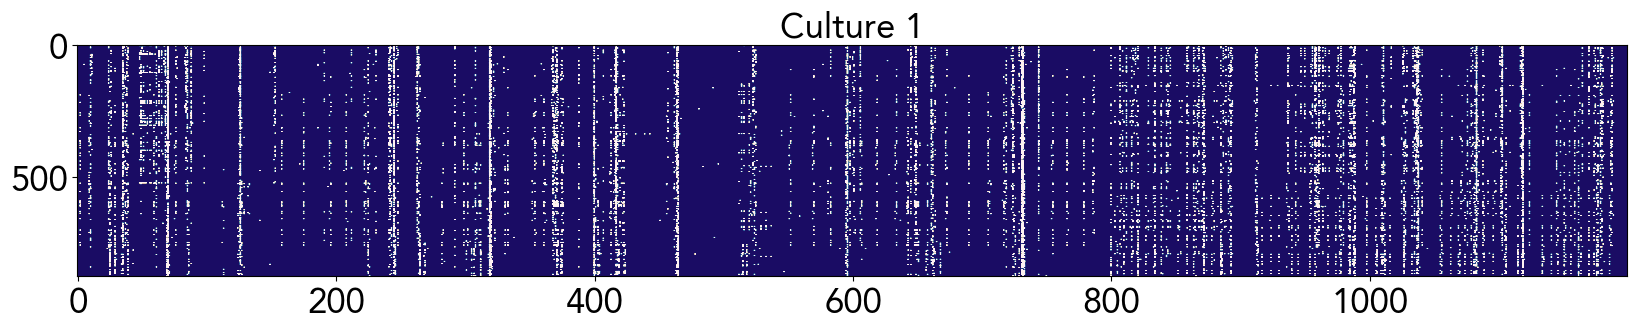

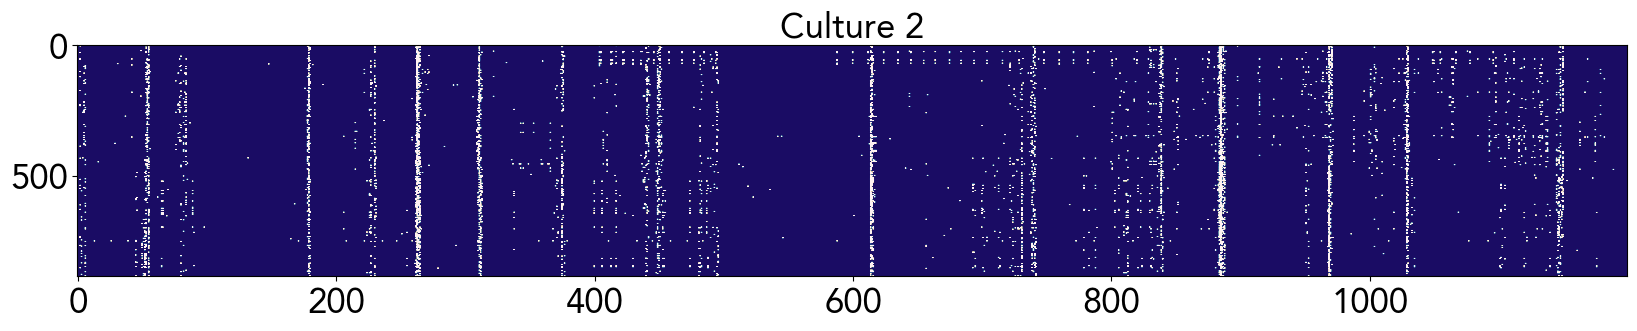

In [51]:
t    = np.arange(s_counts.shape[0])*bin_sz 
plt.subplots(figsize=(20,3))
plt.imshow(s_counts[(t<12)].T,aspect='auto', cmap=Cmap('lapaz'),vmin=0, vmax=0.1,)
plt.title('Culture 1')

t    = np.arange(s_counts2.shape[0])*bin_sz 
plt.subplots(figsize=(20,3))
plt.imshow(s_counts2[(t<12)].T,aspect='auto', cmap=Cmap('lapaz'),vmin=0, vmax=0.1,)
plt.title('Culture 2')

## 1.2 effective connectivity (EC)

TE, SC, XCov computed from 30 mins spontaneous activity.

In [30]:
# CULTURE 1
_TE,  _TE_sign,  _zTE,  _zTE_sign, _TE_Pval   = lec.load_complete_measures(main_path, sim_folder, folder_prefix='ECdata_', file_prefix='Cult_'+str(T_spont)+'min_', ECmeas = 'TE',  tp = 'pk', alpha=alpha_th)
# limiting positive values
thresholdsP = [-5.6, 0.6, -5.85]; thr_noSig_P = [-7.1, 0., -6.7]
cond = (_TE<10**thr_noSig_P[0]); _TE[cond]=0; del cond; cond = (_TE_sign<10**thresholdsP[0]); _TE_sign[cond]=0;  del cond
# (source x target) IC matrix has size: (nStimChannels, nChannels) – To compare EC with IC - we restrict (source x target) EC matrices from (nChannels, nChannels) to (nStimChannels, nChannels)
sort_ids = np.arange(len(channel))
TE   = _TE[np.ix_(indices,sort_ids)];  TE_sign = _TE_sign[np.ix_(indices,sort_ids)];  
zTE = _zTE[np.ix_(indices,sort_ids)];  zTE_sign = _zTE_sign[np.ix_(indices,sort_ids)]; TE_Pval = _TE_Pval[np.ix_(indices,sort_ids)];
# distance matrix
dist_mat = (lec.load_mat(main_path, sim_folder, binsize=0.3, file_prefix='Cult_'+str(T_spont)+'min_', folder_prefix='ECdata_TE', ECmeas='DistanceMat', suffix='', mat_type='mat_d'))/1000
Dmat     = dist_mat[np.ix_(indices,sort_ids)]

In [53]:
# CULTURE 2
_TE,  _TE_sign,  _zTE,  _zTE_sign, _TE_Pval   = lec.load_complete_measures(main_path, sim_folder2, folder_prefix='ECdata_', file_prefix='Cult_'+str(T_spont)+'min_', ECmeas = 'TE',  tp = 'pk', alpha=alpha_th)
# limiting positive values
thresholdsP = [-6, 0.5, -6.2]; thr_noSig_P = [-7.5, 0.4, -7]
cond = (_TE<10**thr_noSig_P[0]); _TE[cond]=0; del cond; cond = (_TE_sign<10**thresholdsP[0]); _TE_sign[cond]=0;  del cond
# (source x target) IC matrix has size: (nStimChannels, nChannels) – To compare EC with IC - we restrict (source x target) EC matrices from (nChannels, nChannels) to (nStimChannels, nChannels)
sort_ids = np.arange(len(channel2))
TE2  = _TE[np.ix_(indices2,sort_ids)];  TE_sign2 = _TE_sign[np.ix_(indices2,sort_ids)];  
zTE2 = _zTE[np.ix_(indices2,sort_ids)]; zTE_sign2 = _zTE_sign[np.ix_(indices2,sort_ids)]; TE_Pval2 = _TE_Pval[np.ix_(indices2,sort_ids)];
# distance matrix
dist_mat2 = (lec.load_mat(main_path, sim_folder2, binsize=0.3, file_prefix='Cult_'+str(T_spont)+'min_', folder_prefix='ECdata_TE', ECmeas='DistanceMat', suffix='', mat_type='mat_d'))/1000
Dmat2     = dist_mat2[np.ix_(indices2,sort_ids)]

## 1.3 interventional connectivity (IC)

In [ ]:
ks_loading    = False       # do not change in False: ORIGINAL DATA ARE NOT SHARED on github
sort_ids = np.arange(len(channel))

if ks_loading is False:
    ks, ks_sign, ks_pval_FDR, ks_pval  = IC.compute_KS(Ntrials, def_units, def_chans, def_spikes, channel, stim_start, Delta_pre, 
                                                       stim_stop, Delta_post, Tmax, alpha_th=alpha_th, id_trial_start=0, n_jobs=1, verbose=True)
    # store data:
    ic_save(path_IC_data, ks, ks_pval, ks_pval_FDR)
else:
    # load data
    ks, ks_pval, ks_pval_FDR = ic_load(path_IC_data)
    ks_sign     = np.copy(ks); ks_sign[ks_pval>alpha_th] = 0
    #ks_sign_FDR = np.copy(ks); ks_sign_FDR[ks_pval_FDR>alpha_th] = 0

ks      = ks[:,sort_ids]
ks_sign = ks_sign[:,sort_ids]
ks_pval = ks_pval[:,sort_ids]

#==============================================#

ks_bin_loading = False       # do not change in False: ORIGINAL DATA ARE NOT SHARED on github

if ks_bin_loading is False:
    # binning size for spike count
    dT_ks         = 40 * ms_bins
    Nbins_ks      = Tmax // dT_ks
    print(dT_ks, Nbins_ks)
    ks_bin, ks_sign_bin, ks_pval_FDR_bin, ks_pval_bin  = IC.compute_KS_binned(Ntrials, def_units, def_chans, def_spikes, channel, 
                                                                              stim_start, Delta_pre, stim_stop, Delta_post, Tmax, Nbins=Nbins_ks, alpha_th=alpha_th, id_trial_start=0, n_jobs=1, verbose=True)    
    # store data:
    ic_save(path_ICbin_data, ks_bin, ks_pval_bin, ks_pval_FDR_bin)
else:
    # load data

    ks_bin, ks_pval_bin, ks_pval_FDR_bin = ic_load(path_IC_data)
    ks_sign_bin     = np.copy(ks_bin); ks_sign_bin[ks_pval_bin>alpha_th] = 0; ks_sign_bin[np.isnan(ks_bin)]=0
    #ks_sign_FDR_bin = np.copy(ks_bin); ks_sign_FDR_bin[ks_pval_FDR_bin>alpha_th] = 0; ks_sign_FDR_bin[np.isnan(ks_bin)]=0

ks_bin      = ks_bin[:,sort_ids]
ks_sign_bin = ks_sign_bin[:,sort_ids]
ks_pval_bin = ks_pval_bin[:,sort_ids]


In [54]:
ks_loading    = False       # do not change in False: ORIGINAL DATA ARE NOT SHARED on github
sort_ids = np.arange(len(channel2))

if ks_loading is False:
    ks2, ks_sign2, ks_pval_FDR2, ks_pval2  = IC.compute_KS(Ntrials2, def_units2, def_chans2, def_spikes2, channel2, stim_start, Delta_pre, 
                                                       stim_stop, Delta_post, Tmax, alpha_th=alpha_th, id_trial_start=0, n_jobs=1, verbose=True)
    # store data:
    ic_save(path_IC_data, ks2, ks_pval2, ks_pval_FDR2)
else:
    # load data
    ks2, ks_pval2, ks_pval_FDR2 = ic_load(path_IC_data2)
    ks_sign2     = np.copy(ks2); ks_sign2[ks_pval2>alpha_th] = 0
    #ks_sign_FDR = np.copy(ks); ks_sign_FDR[ks_pval_FDR>alpha_th] = 0

ks2      = ks2[:,sort_ids]
ks_sign2 = ks_sign2[:,sort_ids]
ks_pval2 = ks_pval2[:,sort_ids]

#==============================================#

ks_bin_loading = False       # do not change in False: ORIGINAL DATA ARE NOT SHARED on github

if ks_bin_loading is False:
    # binning size for spike count
    dT_ks         = 40 * ms_bins
    Nbins_ks      = Tmax // dT_ks
    print(dT_ks, Nbins_ks)
    ks_bin2, ks_sign_bin2, ks_pval_FDR_bin2, ks_pval_bin2  = IC.compute_KS_binned(Ntrials2, def_units2, def_chans2, def_spikes2, channel2, 
                                                                              stim_start, Delta_pre, stim_stop, Delta_post, Tmax, Nbins=Nbins_ks, alpha_th=alpha_th, id_trial_start=0, n_jobs=1, verbose=True)    
    # store data:
    ic_save(path_ICbin_data2, ks_bin2, ks_pval_bin2, ks_pval_FDR_bin2)
else:
    # load data
    ks_bin2, ks_pval_bin2, ks_pval_FDR_bin2 = ic_load(path_IC_data2)
    ks_sign_bin2     = np.copy(ks_bin2); ks_sign_bin2[ks_pval_bin2>alpha_th] = 0; ks_sign_bin2[np.isnan(ks_bin2)]=0
    #ks_sign_FDR_bin2 = np.copy(ks_bin2); ks_sign_FDR_bin2[ks_pval_FDR_bin2>alpha_th] = 0; ks_sign_FDR_bin2[np.isnan(ks_bin2)]=0

ks_bin2      = ks_bin2[:,sort_ids]
ks_sign_bin2 = ks_sign_bin2[:,sort_ids]
ks_pval_bin2 = ks_pval_bin2[:,sort_ids]



Computing time-indep. KOLMOGOROV-SMIRNOV....
....done

800 12

Computing binned KS with Nbins = 12...
....done



# 2. Channel response to perturbation

## 2.1 Channel maps

### 2.1.1 channel map

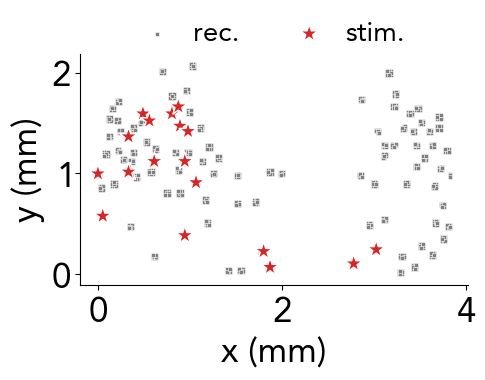

In [125]:
# most responsive channels
in_sign_bin = np.sum(ks_sign_bin,axis=0)

array_cols = ['tab:red' for i in range(len(indices))]
plot_map_rec(pos, 'grey', channel, def_chans, indices, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 180, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=2, y_leg=1.25, cmap = None,
                   outf=path_imgs+'1.1channel_map_culture1.pdf', show_plot=show_plot)


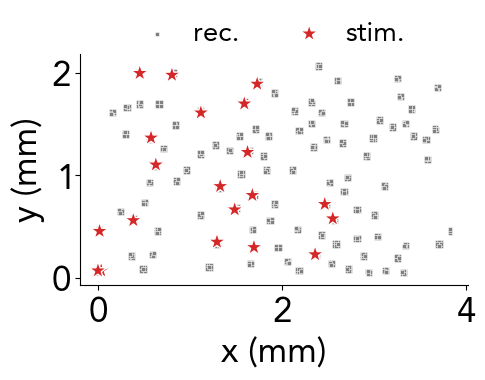

In [126]:
# most responsive channels
in_sign_bin = np.sum(ks_sign_bin2,axis=0)

array_cols = ['tab:red' for i in range(len(indices2))]
plot_map_rec(pos2, 'grey', channel2, def_chans2, indices2, array_cols, figsize=(5, 3), cbar_label='channel in-strength', dotcolor='lightgray',
                   dotsize=10, starsize = 180, text_dim = 20, dim = 60/3, font_DIM=25, ncol_leg=2, y_leg=1.25, cmap = None,
                   outf=path_imgs+'1.1channel_map_culture2.pdf', show_plot=show_plot)


### 2.1.2 channel map – rec channels highlighted 

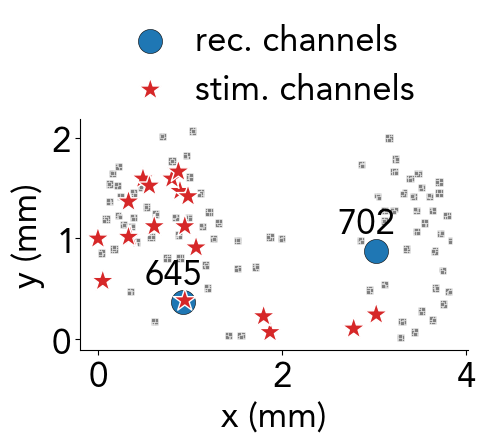

In [127]:
array_cols = ['tab:red' for i in range(len(indices))]
plot_channel_map_3(pos, [645,702], [645,702], channel, def_chans, indices, array_cols, rec_color='tab:blue', figsize=(5, 3), dotcolor='grey',
                   dotsize=20, starsize = 300, starsize_center = None, text_dim = 25, dim = 60/3, font_DIM=25, ncol_leg=1, y_leg=1.55,
                   rec_text=True, cmap=None,ax=None,  outf=path_imgs+'1.2_II_channels_map_rec_culture1.pdf', show_plot=show_plot)

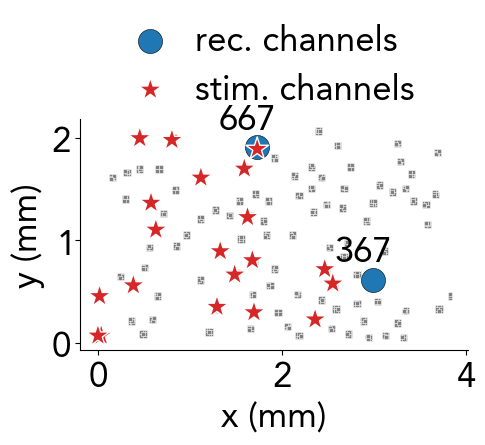

In [128]:
array_cols = ['tab:red' for i in range(len(indices2))]
plot_channel_map_3(pos2, [367,667], [367,667], channel2, def_chans2, indices2, array_cols, rec_color='tab:blue', figsize=(5, 3), dotcolor='gray',
                   dotsize=20, starsize = 300, starsize_center = None, text_dim = 25, dim = 60/3, font_DIM=25, ncol_leg=1, y_leg=1.55,
                   rec_text=True, cmap=None,ax=None,  outf=path_imgs+'1.2_II_channels_map_rec_culture2.pdf', show_plot=show_plot)

## 2.2 100 rec. channels with highest in-strength – plot IC/TE as function of distance from stim.channel

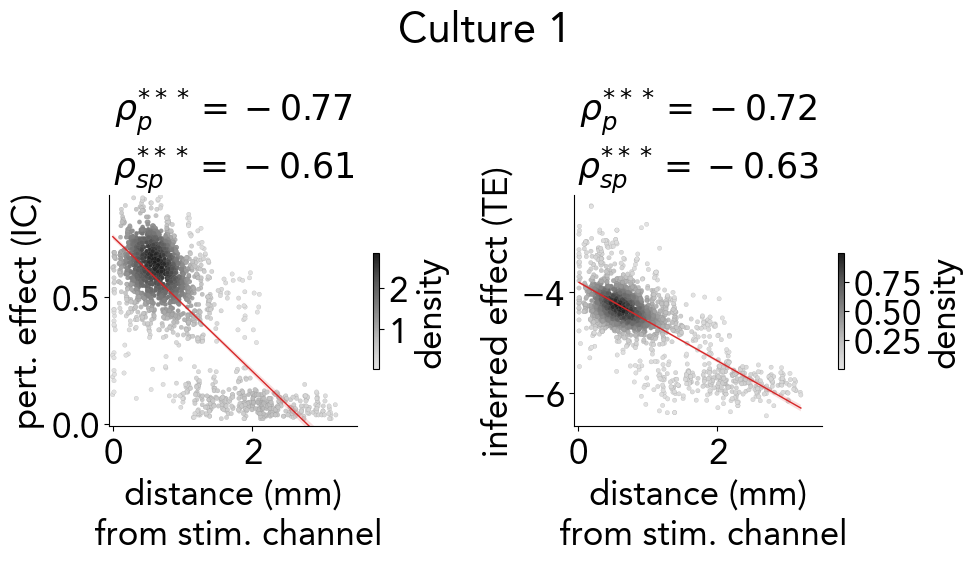

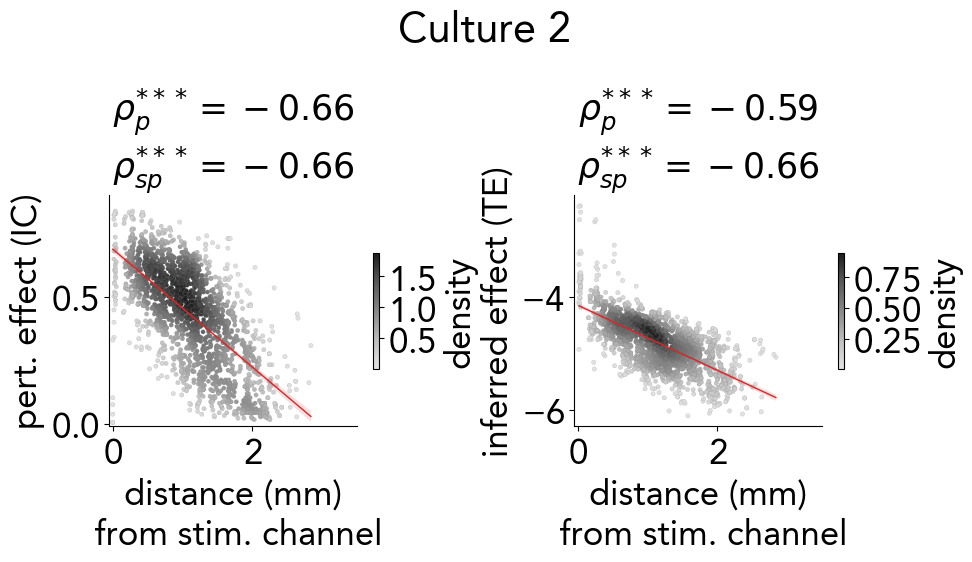

In [129]:
cmap    = truncate_cmap(plt.get_cmap('Greys'), minval=0.2, maxval=0.9)
dotsize = 10

for IC_mat, TE_mat, cult_save, cult_lab, _channel, _pos, _def_units, _def_chans in zip([ks,ks2], [TE,TE2], ['culture1','culture2'], ['Culture 1','Culture 2'], [channel,channel2], [pos,pos2], [def_units,def_units2], [def_chans,def_chans2] ):
    
    in_sign_bin = np.sum(IC_mat,axis=0)
    L           = np.argsort(in_sign_bin)[::-1]
    
    fig,axs = plt.subplots(1,2,figsize=(10,3))
    for y, lab, log, ax in zip([IC_mat, TE_mat], ['IC','TE'], [False,True], axs):
    
        dists  = []
        y_vals = []
        
        for i in range(100):
            i_rec   = int(np.where(in_sign_bin==in_sign_bin[L[i]])[0][0])
            sorted_units, sorted_d = sort_units_with_distance(i_rec, _channel, _pos/1000, _def_units, _def_chans)
            dists   = np.concatenate([dists, sorted_d])
            y_vals = np.concatenate([y_vals, y[sorted_units,i_rec]])
        
        title   = None # lab+'\n'+f'rec. chan. {i_rec}'
        xlabel  = 'distance (mm)\n from stim. channel'
        
        if log==False:
            ylabel  = 'pert. effect (IC)'
            plot_scatter(dists, y_vals, -8, xlabel=xlabel, ylabel=ylabel, dotsize=dotsize, edgecolor='grey', linewidths=0.1, 
                         dotcolor='k', figsize=(4,3), xmin=-0.05, xmax=3.5, ymin=-0.01, ymax=0.9,
                         log=log,reg_line=True,  ax = ax, regcolor='tab:red', cmap=cmap, title=title, outf=path_imgs + f'2.0.3.1_IC_vs_rec_distances_{lab}.pdf', show_plot=show_plot)
        else:
            ylabel  = 'inferred effect (TE)'
            plot_scatter(dists, y_vals, -8, xlabel=xlabel, ylabel=ylabel, dotsize=dotsize, edgecolor='grey', linewidths=0.1, 
                         dotcolor='k', figsize=(4,3), xmin=-0.05, xmax=3.5, #ymin=-0.01, ymax=0.8,
                         log=log,reg_line=True,  ax = ax, regcolor='tab:red', cmap=cmap, title=title, outf=path_imgs + f'2.0.3.1_IC_vs_rec_distances_{lab}.pdf', show_plot=show_plot)        
    
    fig.subplots_adjust(wspace=0.5)
    fig.suptitle(cult_lab,y=1.5)
    plt.savefig(path_imgs+f'2.1_edge_vs_rec_distances_{cult_save}.pdf', bbox_inches='tight')
    

## 2.2 focus: 1 rec. channel - channel response vs. stim channel distances

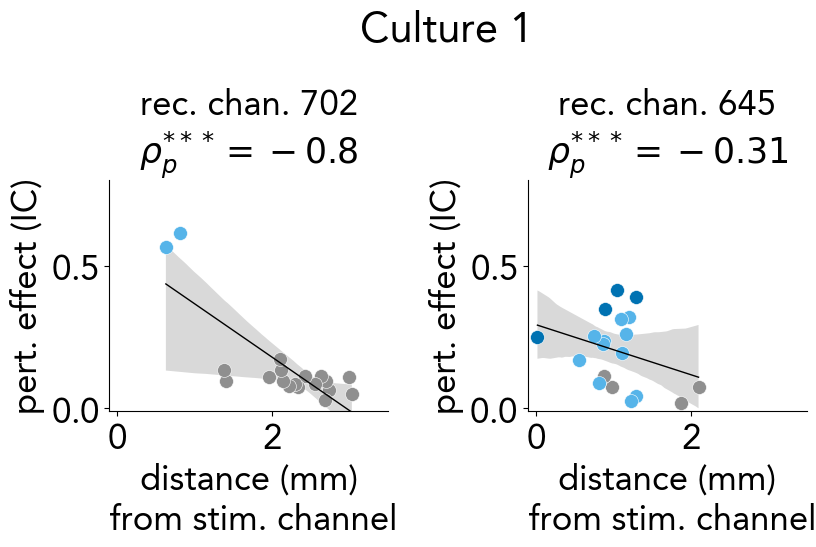

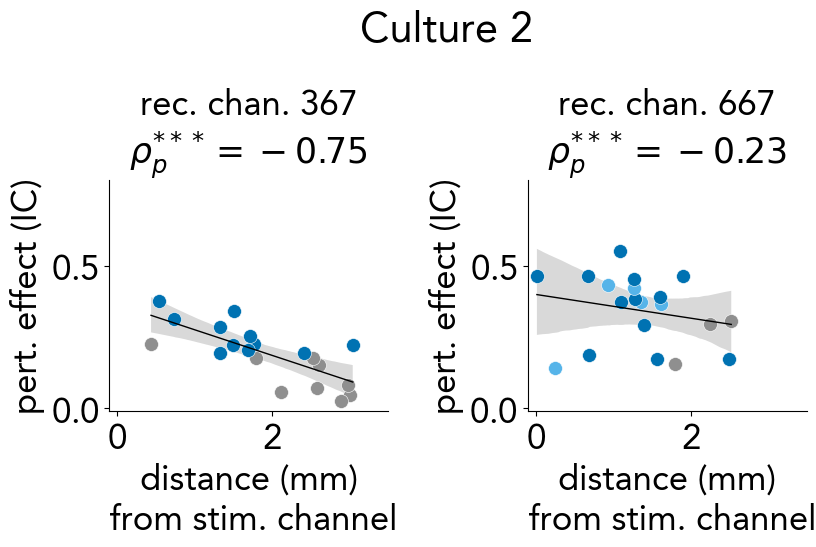

In [130]:
col_d = '#0072B2'
col_u = '#56B4E9'
col_n = '#8F8F8F'

dotsize = 100; KS = ks
col_645 = [col_d, col_u,col_u,col_u,col_u,col_u, col_n, col_d, col_n, col_d, col_u,col_u,col_u,col_u,col_u, col_d, col_u, col_n,col_n][::-1]
col_702 = [col_u, col_u, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n][::-1]

col_367 = [col_n, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_d, col_n, col_n, col_n, col_n, col_n, col_n, col_d][::-1]
col_667 = [col_d, col_u, col_d, col_d, col_u, col_d, col_d, col_d, col_u, col_d, col_u, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_n][::-1]

show_corr = True
reg_line  = False
regcolor  = 'k'
reg_line=True

for KS, rec_chans, rec_cols, cult_save, cult_lab, _channel, _pos, _def_units, _def_chans in zip([ks,ks2],[[702,645],[367, 667]], 
                                                                                                [[col_702,col_645],[col_367,col_667]],
                                                                                                ['culture1','culture2'], 
                                                                                                ['Culture 1','Culture 2'], 
                                                                                                [channel,channel2], [pos,pos2], 
                                                                                                [def_units,def_units2], 
                                                                                                [def_chans,def_chans2] ):

    fig,axs = plt.subplots(1,2,figsize=(9,3))
    for i_rec, col_post,ax in zip(rec_chans, rec_cols, axs):
        sorted_units, sorted_d = sort_units_with_distance(i_rec, _channel, _pos/1000, _def_units, _def_chans)
        
        title  = f'rec. chan. {i_rec}'
        ylabel = 'pert. effect (IC)'
        xlabel = 'distance (mm)\n from stim. channel'
    
        x = sorted_d
        y = KS[sorted_units,i_rec]
        
        if reg_line:
            sns.regplot(x=x, y=y, ax=ax, scatter=False, color=regcolor, line_kws={'linewidth': 1})
        for i in range(len(sorted_d)):
            ax.scatter(x[i], y[i], s = dotsize, c=col_post[i], edgecolor='white', linewidths=0.4)
        
        if show_corr:
            cp = np.round(pearsonr(x,y)[0],2)
            cs = np.round(spearmanr(x,y)[0],2)
            pval_p = pearsonr(x,y)[1]
            pval_s = spearmanr(x,y)[1]
            if title:
                ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$')#+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
            else:
                ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$')#+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            if title:
                ax.set_title(title)
        ax.set_ylim(-0.01,0.8)
        ax.set_xlim(-0.1,3.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        pl.set_format(ax=ax, DIM=DIM, pwr_x_min=-2, pwr_y_min=-2)
    fig.subplots_adjust(wspace=0.5)
    fig.suptitle(cult_lab,y=1.45)
    
    if reg_line:
        fig.savefig(path_imgs + f'2.2_IC_vs_rec{i_rec}_distance_regline_{cult_save}.pdf', bbox_inches='tight')
    else:
        fig.savefig(path_imgs + f'2.2_IC_vs_rec{i_rec}_distance_{cult_save}.pdf', bbox_inches='tight')


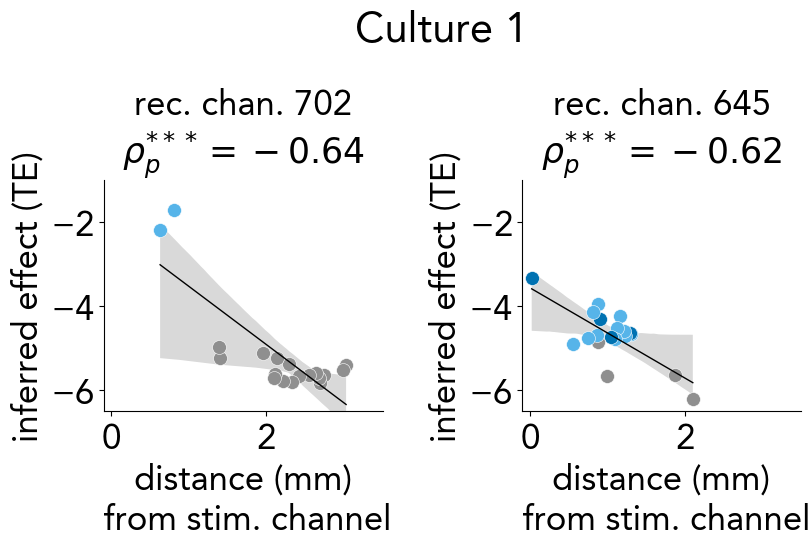

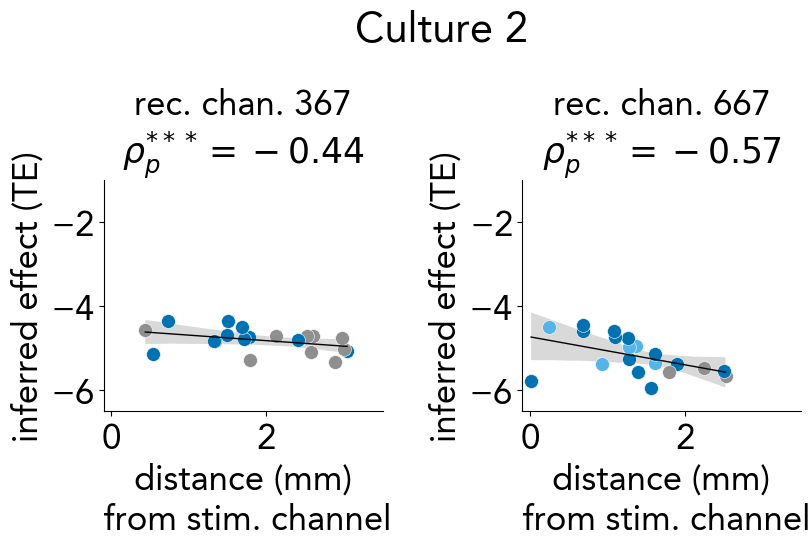

In [131]:
col_d = '#0072B2'
col_u = '#56B4E9'
col_n = '#8F8F8F'

dotsize = 100; KS = ks
col_645 = [col_d, col_u,col_u,col_u,col_u,col_u, col_n, col_d, col_n, col_d, col_u,col_u,col_u,col_u,col_u, col_d, col_u, col_n,col_n][::-1]
col_702 = [col_u, col_u, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n, col_n][::-1]

col_367 = [col_n, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_d, col_n, col_n, col_n, col_n, col_n, col_n, col_d][::-1]
col_667 = [col_d, col_u, col_d, col_d, col_u, col_d, col_d, col_d, col_u, col_d, col_u, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_n][::-1]

show_corr = True
reg_line  = False
regcolor  = 'k'
reg_line=True

for KS, rec_chans, rec_cols, cult_save, cult_lab, _channel, _pos, _def_units, _def_chans in zip([TE,TE2],[[702,645],[367, 667]], 
                                                                                                [[col_702,col_645],[col_367,col_667]],
                                                                                                ['culture1','culture2'], 
                                                                                                ['Culture 1','Culture 2'], 
                                                                                                [channel,channel2], [pos,pos2], 
                                                                                                [def_units,def_units2], 
                                                                                                [def_chans,def_chans2] ):

    fig,axs = plt.subplots(1,2,figsize=(9,3))
    for i_rec, col_post,ax in zip(rec_chans, rec_cols, axs):
        sorted_units, sorted_d = sort_units_with_distance(i_rec, _channel, _pos/1000, _def_units, _def_chans)
        
        title  = f'rec. chan. {i_rec}'
        ylabel = 'inferred effect (TE)'
        xlabel = 'distance (mm)\n from stim. channel'
    
        x = sorted_d
        y = KS[sorted_units,i_rec]
        
        if reg_line:
            sns.regplot(x=x, y=np.log10(y+10**-7), ax=ax, scatter=False, color=regcolor, line_kws={'linewidth': 1})
        for i in range(len(sorted_d)):
            ax.scatter(x[i], np.log10(y+10**-7)[i], s = dotsize, c=col_post[i], edgecolor='white', linewidths=0.4)
        
        if show_corr:
            cp = np.round(pearsonr(x,y)[0],2)
            cs = np.round(spearmanr(x,y)[0],2)
            pval_p = pearsonr(x,y)[1]
            pval_s = spearmanr(x,y)[1]
            if title:
                ax.set_title(title+'\n'+rf'$\rho_{{p}}^{{***}}={cp}$')#+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
            else:
                ax.set_title(rf'$\rho_{{p}}^{{***}}={cp}$')#+'\n'+rf'$\rho_{{sp}}^{{***}}={cs}$')
        else:
            if title:
                ax.set_title(title)
        ax.set_ylim(-6.5,-1)
        ax.set_xlim(-0.1,3.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        pl.set_format(ax=ax, DIM=DIM, pwr_x_min=-2, pwr_y_min=-2)
    fig.subplots_adjust(wspace=0.5)
    fig.suptitle(cult_lab,y=1.45)

    if reg_line:
        fig.savefig(path_imgs + f'2.3_TE_vs_rec{i_rec}_distance_regline_{cult_save}.pdf', bbox_inches='tight')
    else:
        fig.savefig(path_imgs + f'2.3_TE_vs_rec{i_rec}_distance_{cult_save}.pdf', bbox_inches='tight')


# 3. Spike counts responses

In [25]:
# test: sort stimulation units with distance (from closer to farther)  from a rec. channel – in this example rec. channel = 100 
sorted_units, sorted_d = sort_units_with_distance(100, channel, pos, def_units, def_chans)


## 3.1 store the spike counts for each stim unit and for each trial

In [94]:
# CULTURE 1
# store the spike counts for each stim unit and for each trial
# counts_dict: pre + stim + post  blocks are consecutive 

counts_dict = {}
for bin_sz in [0.01, 0.02, 0.04]:
    # compute spike counts
    s_counts = compute_spike_counts(spikes, binsize=bin_sz)
    counts_dict[bin_sz] = {}
    
    trial_block = len(def_units)*DeltaT_sec
    for i_unit in range(len(def_units)):
        counts_dict[bin_sz][i_unit] = {}
        for n in range(Ntrials):
            tbin_min = int(int(trial_block) * n + int(DeltaT_sec) * i_unit ) * int(1/bin_sz)
            tbin_max = int(int(trial_block) * n + int(DeltaT_sec) * i_unit ) * int(1/bin_sz) + int(3.8/bin_sz)
            counts_dict[bin_sz][i_unit][n] = (s_counts[tbin_min:tbin_max,:])


In [92]:
# CULTURE 2
# store the spike counts for each stim unit and for each trial
# counts_dict: pre + stim + post  blocks are consecutive 

counts_dict2 = {}
for bin_sz in [0.01, 0.02, 0.04]:
    # compute spike counts
    s_counts2 = compute_spike_counts(spikes2, binsize=bin_sz)
    counts_dict2[bin_sz] = {}
    
    trial_block = len(def_units2)*DeltaT_sec
    for i_unit in range(len(def_units2)):
        counts_dict2[bin_sz][i_unit] = {}
        for n in range(Ntrials2):
            tbin_min = int(int(trial_block) * n + int(DeltaT_sec) * i_unit ) * int(1/bin_sz)
            tbin_max = int(int(trial_block) * n + int(DeltaT_sec) * i_unit ) * int(1/bin_sz) + int(3.8/bin_sz)
            counts_dict2[bin_sz][i_unit][n] = (s_counts2[tbin_min:tbin_max,:])


## 3.2 Choose a recording channel. For each stimulation channel store all trials, with stim progression sorted by distance

### 3.2.1 plot (stim-rec) SPIKE COUNTS trials

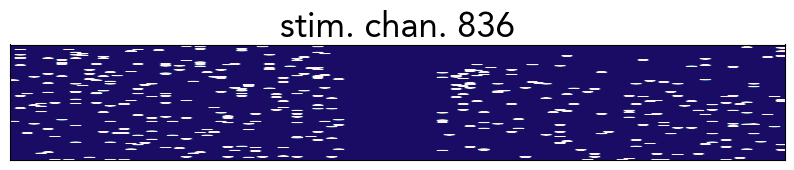

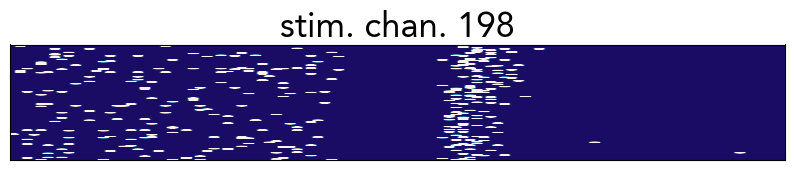

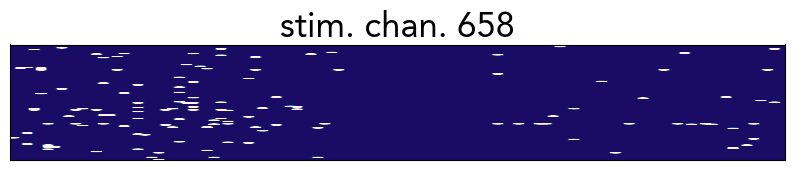

In [145]:
# CULTURE 1
bin_sz = 0.01
for i_rec in [645]:
    sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
    
    
    for i_unit, ax in zip(sorted_units,axs):
        if np.isin(indices[i_unit], np.array([658, 198, 836])):
            fig,ax = plt.subplots(1,1,figsize=(10,1.5))
            trials = (counts_dict[bin_sz][i_unit][0])[int(0.5/bin_sz):int(1.62/bin_sz),i_rec]
            for n in range(1,Ntrials):
                trials = np.vstack([ trials, (counts_dict[bin_sz][i_unit][n])[int(0.5/bin_sz):int(1.62/bin_sz),i_rec]])
            ax.imshow(trials,aspect='auto', cmap=Cmap('lapaz'),vmin=0, vmax=0.1,)
            fig.subplots_adjust(hspace=0.4)
            ax.set_title(f'stim. chan. {indices[i_unit]}')
            ax.set_xticks([])
            ax.set_yticks([])
            plt.savefig(path_imgs + f'3.1_spike_counts{i_rec}_stim{indices[i_unit]}_culture1.pdf', bbox_inches='tight')
        else:
            pass

### 3.2.2 Choose a recording channel. Plot SPIKE COUNTS trials, for all stim channels sorted by distance

In [109]:
def plot_counts(i_rec, sorted_units, indices, counts_dict, bin_sz=0.01, pre_start = 0.5, post_stop=1.62, stim0=1.,stim_end=1.12, 
                figsize=(5,6), outf:str=None, show_plot=False):
    
    fig,ax = plt.subplots(figsize=figsize)

    # stack trials for each stim unit/channel
    trials = (counts_dict[0][0])[:,i_rec]
    for i_unit in sorted_units:
        if i_unit!=0:
            nstart=0
        else:
            nstart=1
        for n in range(nstart,Ntrials):
            trials = np.vstack([ trials, (counts_dict[i_unit][n])[:,i_rec]])
            
    # from bins to time
    t    = np.arange(trials.shape[1])*bin_sz

    condition = (t>=pre_start) & (t<post_stop)
    ax.imshow(trials[:,condition], aspect='auto', cmap=Cmap('lapaz'), vmin=0, vmax=0.1)
    
    # separate trials related to different stim channels with a white line
    for i, i_unit in enumerate(sorted_units):
        ax.plot([0,int((post_stop-pre_start)/bin_sz)], [i*Ntrials,i*Ntrials], color='white',lw=2)
    
    # white stripe where stimulation occurs    
    ax.fill_between([int((stim0-pre_start)/bin_sz),int((stim_end-pre_start)/bin_sz)], 0, len(def_units)*Ntrials, color='white',alpha=1)

    # label stim channels (sorted by distance from rec channel)
    k=0
    for idx in sorted_units:
        plt.text(int((stim0-pre_start)/bin_sz)+6., (k*Ntrials)+Ntrials/2-20, str(int(indices[idx])), color='black',
         fontsize=DIM-10, ha='center', va='center')
        k+=1

    # set limits to constrain lines
    ax.set_xlim(0,int((post_stop-pre_start)/bin_sz))
    ax.set_ylim(0,Ntrials*len(indices))

    # 
    despine_all(fig)
    ax.set_xticks([])
    ax.set_yticks([])

    fig.set_facecolor('none')
    plt.title('channel '+str(i_rec)+ ' response',fontsize=DIM)

    if outf:
        plt.savefig(outf, bbox_inches='tight')
        if show_plot==False:
            plt.close()
            

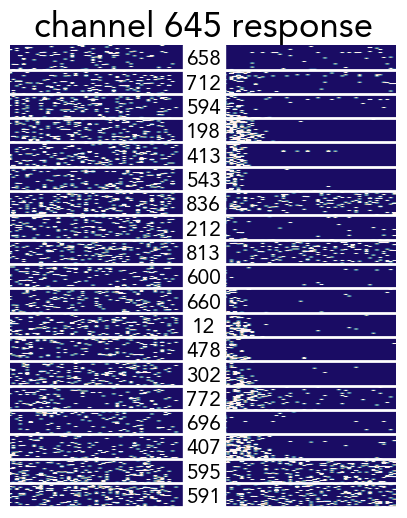

In [133]:
bin_sz = 0.01
for i_rec in [645]:#,702,82,578]:
    sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
    plot_counts(i_rec, sorted_units, indices, counts_dict[bin_sz], bin_sz=bin_sz, figsize=(5,6), outf=path_imgs+f'3.2_spike_counts_recChan_{i_rec}_culture1.pdf', show_plot=show_plot)
    

# 4. Average responses

## 4.1 PLOT TRACES (all trial)

Choose a recording channel. For each stim channel, do the mean of the trial spike counts. Sort the plot order by rec-stim distance

In [122]:
def plot_traces(i_rec, sorted_units, indices, counts_dict, col_post, col_n, bin_sz=0.01, n_ampli=10,  Ntrials=200,
                pre_start=0.49, pre_stop=0.99, post_start=1+0.12, post_stop=1.12, stim0=1, stimEnd=1+0.12, figsize=(5,6), outf:str=None, show_plot=False):

    fig,ax = plt.subplots(figsize=figsize)
    
    for i,i_unit in enumerate(sorted_units):

        # put together trials for each stimulation from i_unit, for fixed i_rec rec-channel
        trials = (counts_dict[i_unit][0])[:,i_rec]
        for n in range(1,Ntrials):
            trials = np.vstack([ trials, (counts_dict[i_unit][n])[:,i_rec]])

        # average spike counts across trials, for each i_unit
        mean = np.sum(trials,axis=0)/Ntrials * n_ampli
        t    = np.arange(len(mean))*bin_sz   

        # zero amplitude of each trial
        ax.plot([pre_start,post_stop], [i,i], color='black',lw=0.1)

        # pulses of stimulation (the exact ones)
        for k in range(24):
            ax.plot([stim0+k*0.005,stim0+k*0.005], [i,i+0.3], color='black',lw=0.1)

        # pre and post traces
        ax.plot(t[(t>pre_start) & (t<=pre_stop)], mean[(t>pre_start) & (t<=pre_stop)] + i, color=col_n, lw=2, alpha=1)
        ax.plot(t[(t>=post_start) & (t<post_stop)], mean[(t>=post_start) & (t<post_stop)] + i, color=col_post[i], lw=2, alpha=1)        

    despine_all(fig)
    
    # y-ticks: stim units
    ax.set_yticks(np.arange(len(indices)))
    ax.set_yticklabels(indices[sorted_units], fontsize=DIM-10)
    ax.set_ylabel('stim. channel',fontsize=DIM)
    
    # no x-ticks
    ax.set_xticks([])
    
    fig.set_facecolor('none')
    plt.title('channel '+str(i_rec)+ ' response',fontsize=DIM)
    
    if outf:
        plt.savefig(outf, bbox_inches='tight')
        if show_plot==False:
            plt.close()


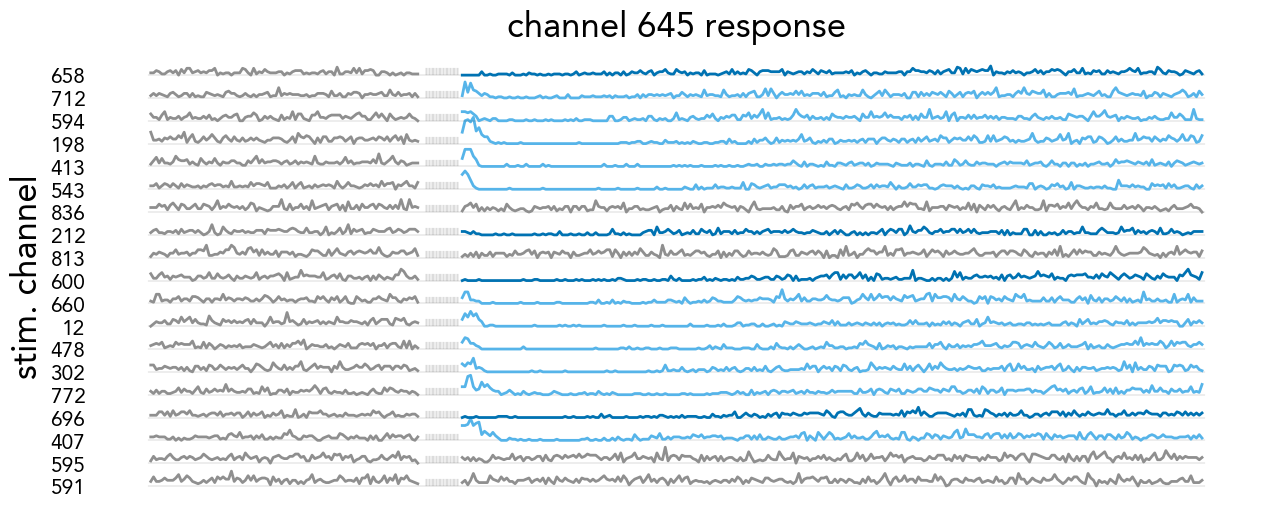

In [134]:
col_d = '#0072B2'
col_u = '#56B4E9'
col_n = '#8F8F8F'

#CUTLURE 1
for i,bin_sz in enumerate([0.01]): #,0.02,0.04]):
    i_rec = 645
    col_post = [col_d, col_u,col_u,col_u,col_u,col_u, col_n, col_d, col_n, col_d, col_u,col_u,col_u,col_u,col_u, col_d, col_u, col_n,col_n][::-1]
    sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
    plot_traces(i_rec, sorted_units, indices, counts_dict[bin_sz], col_post, col_n, bin_sz=bin_sz, n_ampli=10/(i+1), 
                pre_start=0, pre_stop=0.97, post_start=1.13, post_stop=3.8, stim0=1., stimEnd=1.+0.12,
                figsize=(15,6), outf=path_imgs+f'4.1_tracesAlltrial_recChan_{i_rec}_bs_{int(bin_sz*1000)}ms_culture1.pdf', show_plot=show_plot)


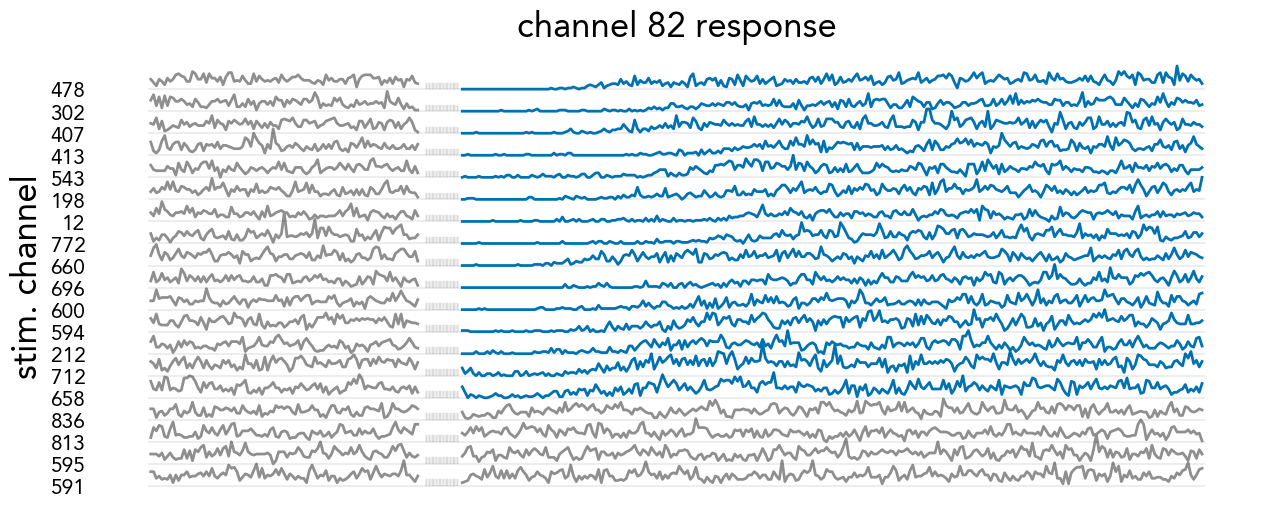

In [135]:
#CUTLURE 1
for i,bin_sz in enumerate([0.01]): #,0.02,0.04]):
    i_rec = 82
    col_post = [col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_d, col_n, col_n, col_n, col_n][::-1]
    sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
    plot_traces(i_rec, sorted_units, indices, counts_dict[bin_sz], col_post, col_n, bin_sz=bin_sz, n_ampli=10/(i+1), 
                pre_start=0, pre_stop=0.97, post_start=1.13, post_stop=3.8, stim0=1., stimEnd=1.+0.12,
                figsize=(15,6), outf=path_imgs+f'4.1_tracesAlltrial_recChan_{i_rec}_bs_{int(bin_sz*1000)}ms_culture1.pdf', show_plot=show_plot)


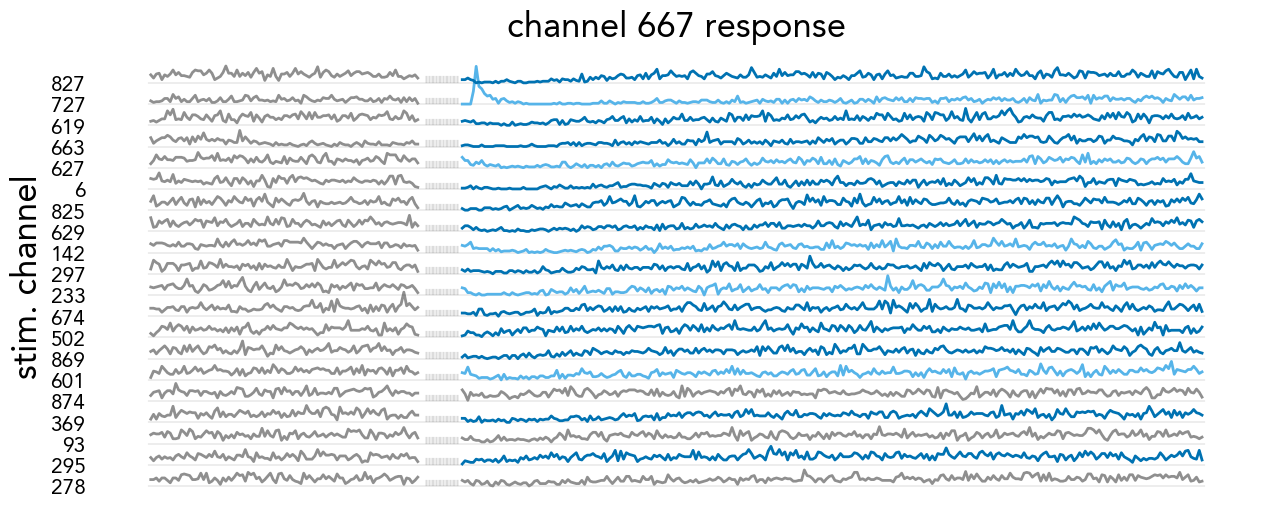

In [136]:
for i,bin_sz in enumerate([0.01]): #,0.02,0.04]):
    i_rec = 667
    col_post = [col_d, col_u, col_d, col_d, col_u, col_d, col_d, col_d, col_u, col_d, 
                col_u, col_d, col_d, col_d, col_u, col_n, col_d, col_n, col_d, col_n][::-1]
    sorted_units, sorted_d = sort_units_with_distance(i_rec, channel2, pos2, def_units2, def_chans2)
    plot_traces(i_rec, sorted_units, indices2, counts_dict2[bin_sz], col_post, col_n, bin_sz=bin_sz, n_ampli=7/(i+1), Ntrials=Ntrials2,
                pre_start=0, pre_stop=0.97, post_start=1.13, post_stop=3.8, stim0=1., stimEnd=1.+0.12,
                figsize=(15,6), outf=path_imgs+f'4.1_tracesAlltrial_recChan_{i_rec}_bs_{int(bin_sz*1000)}ms_culture2.pdf', show_plot=show_plot)


## 4.2 PLOT TRACES (in pre/post time windows)

Choose a recording channel. For each stim channel, do the mean of the trial spike counts. Sort the plot order by rec-stim distance

In [119]:
def plot_traces_zoom(i_rec, sorted_units, indices, counts_dict, col_post, col_n, bin_sz=0.01, n_ampli=1, 
                pre_start=0.49, pre_stop=0.99, post_start=1+0.004, post_stop=1.504, stim0=1, stimEnd=1+0.003, figsize=(5,6), outf:str=None, show_plot=False):

    fig,ax = plt.subplots(figsize=figsize)
    
    for i,i_unit in enumerate(sorted_units):

        # put together trials for each stimulation from i_unit, for fixed i_rec rec-channel
        trials = (counts_dict[i_unit][0])[:,i_rec]
        for n in range(1,Ntrials):
            trials = np.vstack([ trials, (counts_dict[i_unit][n])[:,i_rec]])

        # average spike counts across trials, for each i_unit
        mean = np.sum(trials,axis=0)/Ntrials 
        t    = np.arange(len(mean))*bin_sz   

        # zero amplitude of each trial
        ax.plot([pre_start,post_stop], [i,i], color='black',lw=0.1)

        # pulses of stimulation (the exact ones)
        for k in range(24):
            ax.plot([stim0+k*0.005,stim0+k*0.005], [i,i+0.3], color='black',lw=0.1)
        m_pre   = np.mean(mean[(t>pre_start) & (t<=pre_stop)])
        max_pre = np.max(np.abs(mean[(t>pre_start) & (t<=pre_stop)]))
        # pre and post traces
        y_pre  = (mean[(t>pre_start) & (t<=pre_stop)]   - m_pre) / max_pre*0.2 * n_ampli
        y_post = (mean[(t>=post_start) & (t<post_stop)] - m_pre) / max_pre*0.2 * n_ampli
        ax.plot(t[(t>pre_start) & (t<=pre_stop)],   y_pre  + i, color=col_n,       lw=2, alpha=1)
        ax.plot(t[(t>=post_start) & (t<post_stop)], y_post + i, color=col_post[i], lw=2, alpha=1)        

    despine_all(fig)
    
    # y-ticks: stim units
    ax.set_yticks(np.arange(len(indices)))
    ax.set_yticklabels(indices[sorted_units], fontsize=DIM-10)
    ax.set_ylabel('stim. channel',fontsize=DIM)
    
    # no x-ticks
    ax.set_xticks([])
    
    fig.set_facecolor('none')
    plt.title('channel '+str(i_rec)+ ' response',fontsize=DIM)
    
    if outf:
        plt.savefig(outf, bbox_inches='tight')
        if show_plot==False:
            plt.close()


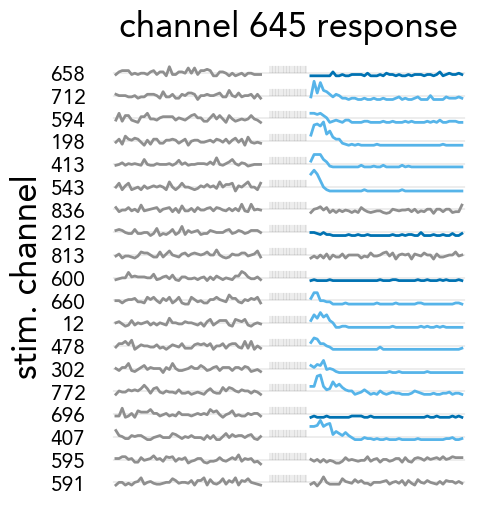

In [137]:
for i,bin_sz in enumerate([0.01]): #,0.02,0.04]):

    i_rec = 645
    col_post = [col_d, col_u,col_u,col_u,col_u,col_u, col_n, col_d, col_n, col_d, col_u,col_u,col_u,col_u,col_u, col_d, col_u, col_n,col_n][::-1]
    sorted_units, sorted_d = sort_units_with_distance(i_rec, channel, pos, def_units, def_chans)
    plot_traces_zoom(i_rec, sorted_units, indices, counts_dict[bin_sz], col_post, col_n, bin_sz=bin_sz, n_ampli=2, 
                pre_start=0.5, pre_stop=0.97, post_start=1.13, post_stop=1.12+0.5, stim0=1., stimEnd=1.12,
                figsize=(5,6), outf=path_imgs+f'5.1_tracesPrePost_recChan_{i_rec}_bs_{int(bin_sz*1000)}ms_culture1.pdf', show_plot=show_plot)
